In [25]:
# Pip install tings and import tings
!pip3 install beautifulsoup4
!pip3 install requests
!pip3 install serpapi
!pip3 install matplotlib
!pip3 install scipi


ERROR: Could not find a version that satisfies the requirement scipi (from versions: none)
ERROR: No matching distribution found for scipi


In [2]:
from bs4 import BeautifulSoup
import requests
#import serpapi
import json
from datetime import datetime
import dateutil.parser as parser
import pandas as pd
import matplotlib.pyplot as plt
import math

This block defines a function that gets all of the specified newspapers' stories that include the given keyword in their headline

In [ ]:
#This dictionary is used by the following function - if paper not recognised [] is returned
# This uses SerpAPI
from bs4 import BeautifulSoup
import requests
import serpapi
import json

papers = {
    'guardian': "www.theguardian.com",
    'dailymail' : "www.dailymail.co.uk"
}

# return a list of articles of form
"""
{headline : text, body: text, date: date, author: author}
"""
def get_all_articles(paper, keyword):
  # Check that paper exists
  if paper.lower() not in papers:
    return []
  searches = []
  end = False

  start = 0

  while(not end):


    params = {
      "q": 'allintitle:"' + keyword + '" site:' + papers[paper] + '',
      "location": "London, United Kingdom",
      "hl": "en",
      "gl": "gb",
      "google_domain": "google.com",
      "api_key": "2603149264d4eac3fc8daef51a3f3f850a97e2dbd117da04880691c595b80274",
      "start": start,
      "output": 'json'
    }

    search = serpapi.search(params).as_dict()
    # Check if any more results have been fetched
    if(search['search_information']['organic_results_state'] == 'Fully empty'):
      end = True
    else:
      searches.append(search)
      start += 10
      print("Done page " + str(start/10))
  return searches

# fake paper name not to drain SERPAPI requests in case I accidentally hate this.
paper_name = 'dailymailAAA'
searchResults = (get_all_articles(paper_name, 'uber'))

json_object = json.dumps(searchResults, indent=4)
with open("raw_" + paper_name + ".json", "w") as outfile:
    outfile.write(json_object)


In [ ]:

# This block of code will convert the extant JSON files into a the final one for analysis (as shown in Template.JSON)

# DAILY MAIL ARTICLE -> FORMAT
# Sanity checks
# Only one headline
# Only one (group) of authors
# Only one date

# First time accessing an article

def read_dailymail_article(url):
  err_obj = {
      'url': url
  }
  # all daily mail articles contain article in url so ignore non-articles
  if 'article' not in url:
    err_obj['failed'] = 'non-article url'
    return err_obj

  # Requests need the url of the page to access
  site = requests.get(url)

  # Beautiful Soup takes the text from the page accessed by requests and makes it easy to use
  # 'html.parser' is the standard way to process HTML in python
  soup = BeautifulSoup(site.text, 'html.parser')

  # Get headline - CHECK THAT THERE IS ONLY ONE HEADLINE


  headline = soup.find_all('h1')
  if len(headline) != 1:
    err_obj['failed'] = 'headline'
    return err_obj

  headline = headline[0].get_text().lower()

  # sometimes headline starts with exclusive without a space, so add a space if so
  if headline.startswith('exclusive'):
    headline = 'exclusive ' + headline.split('exclusive', maxsplit=2)[1].strip()

 # there can be multiple authors
  authors = soup.find_all(class_="author")
  # sometimes authors stored in this tag author-section byline-plain so try this too
  by_for = False
  if len(authors) == 0:
    by_for = True
    authors = soup.find_all(class_="author-section byline-plain")

  # sometimes this tag is used to store multiple authors separated by AND author-section mol-para-with-font byline-plain
  and_separator = False
  if len(authors) == 0:
    and_separator = True
    by_for = False
    authors = soup.find_all(class_="author-section mol-para-with-font byline-plain")

  # check there's at least one
  if len(authors) == 0:
    err_obj['failed'] = 'author'
    return err_obj

  authors = [a.get_text().lower().strip() for a in authors]
  # and_separator means multiple authors separated by and
  if(by_for):
    authors_tmp = authors
    authors = []
    for author in authors_tmp:
      [authors.append(a.strip()) for a in author.split("by ", maxsplit=2)[1].split(' for ', maxsplit=2)[0].split(' and ')]

  if(and_separator):
    authors_tmp = authors
    authors = []
    for author in authors_tmp:
      [authors.append(a.strip()) for a in author.split("by ", maxsplit=2)[1].split(' and ')]

  # Dailymail has published and updated date let's record both
  # Get published time
  published = soup.find(class_ = 'article-timestamp article-timestamp-published')
  if published is None:
    err_obj['failed'] = 'published'
    return err_obj
  published = published.find('time').attrs['datetime']
  published = parser.parse(published)
  # Convert to datetime
  # Get updated time
  updated = soup.find(class_ = 'article-timestamp article-timestamp-updated')
  if updated is not None:
    updated = updated.find('time').attrs['datetime']
    updated = parser.parse(updated)
  else:
    updated = published

  # Get body
  # Ignore subheadings - inconsistent and not always super related to article e.g., it might check out this podcast
  # Ignore captions for photos (will just be repeats from article)
  paragraphs = soup.find_all('p', class_ = 'mol-para-with-font')

  body = ' '.join([p.get_text().strip() for p in paragraphs])

  # Sometimes dailymail articles e.g. https://www.dailymail.co.uk/news/article-2546104/Uber-exposed-dirty-tactics-admitting-attempt-poach-drivers-rival-likely-aggressive.html
  # 's bodies don't have the class, they're just in p tags
  # below code fixes this
  if body.strip() == "":
    paragraphs = soup.find_all('p')
    body = ' '.join([p.get_text().strip() for p in paragraphs])


  # put everything in lower case for purposes of checking for dupes

  return {
      "headline": headline.lower(),
      "authors": authors,
      "published": published.timestamp(),
      "updated": updated.timestamp(),
      "body": body.lower(),
      "url": url
  }

def read_guardian_article(url):
  # Requests need the url of the page to access
  site = requests.get(url)

  # Can't validate URL for guardian because it doesn't contain special string for articles

  # Beautiful Soup takes the text from the page accessed by requests and makes it easy to use
  # 'html.parser' is the standard way to process HTML in python
  soup = BeautifulSoup(site.text, 'html.parser')

  err_obj = {
      'url': url
  }

  # Get headline - CHECK THAT THERE IS ONLY ONE HEADLINE
  headline = soup.find_all('h1')
  if len(headline) != 1:
    err_obj['failed'] = 'headline'
    return err_obj
  headline = headline[0].get_text().lower()


  # Validate authors
  authors = soup.find_all('a', {'rel': 'author'})

  if len(authors) != 0: authors = [author.get_text().strip().lower() for author in authors]

  # Sometimes authors stored elsewhere
  if len(authors) == 0:
    author = soup.find('meta', {'property': 'article:author'})
    if author is not None:
      authors = [author.attrs['content'].strip().lower()]


  if len(authors) == 0:
    err_obj['failed'] = 'author'
    return err_obj



  # Dailymail has published and updated date let's record both
  # Get published time
  published = soup.find('meta', {'property': 'article:published_time'})

  if published is None:
    err_obj['failed'] = 'published'
    return err_obj
  published = published.attrs['content']
  published = parser.parse(published)

  # Get updated time
  updated = soup.find('meta', {'property': 'article:modified_time'})

  if updated is not None:
    updated = updated.attrs['content']
    updated = parser.parse(updated)
  else:
    updated = published

  # Get body
  # Include subheadings - check if it exists first though

  subheading = soup.find_all(class_ = "dcr-1m3qdf6")
  if len(subheading) > 0:
    subheading = subheading[0].get_text().strip() + " "
  else:
    subheading = ""

  # Ignore captions for photos (will just be repeats from article)
  paragraphs = (soup.find_all('p', class_ = "dcr-s3ycb2"))

  body = subheading + ' '.join([p.get_text().strip() for p in paragraphs])

  # put everything in lower case for purposes of checking for dupes

  return {
      "headline": headline.lower(),
      "authors": authors,
      "published": published.timestamp(),
      "updated": updated.timestamp(),
      "body": body.lower(),
      "url": url
  }

#x = read_dailymail_article("https://www.dailymail.co.uk/news/article-14264907/Uber-Eats-different-prices-Coles-chicken.html")
#x = read_guardian_article("https://www.theguardian.com/technology/2017/jun/28/uber-drivers-deserve-to-be-treated-far-better")
#print(x)

In [ ]:
# Using the read daily mail and read guardian functions - let's put our current list into a nicer format

def convert_all_results(paper):
  out = []
  loc = ""

  if paper == 'dailymail':
    loc = './raw_dailymail.json'
  elif paper == 'guardian':
    loc = './raw_guardian.json'
  else:
    return []

  with open(loc, 'r') as f:
    data = json.load(f)
    i = 0
    failed = 0
    for page in data:
      for article in page['organic_results']:
        i += 1
        if paper == 'dailymail': obj = read_dailymail_article(article['link'])
        elif paper == 'guardian': obj = read_guardian_article(article['link'])
        if 'failed' in obj:
          print(obj['failed'] + " : " + article['link'])
          failed += 1
        print(str(i) + " completed, " + str(failed) + " failed")


        out.append(obj)
  return out


articles = convert_all_results('guardian')

with open('clean_guardian.json', 'w') as f:
  json.dump(articles, f)

In [ ]:
# This function merges the clean daily mail and guardian lists
def merge_clean_data(dailymail_loc, guardian_loc):
  merged = {
      'time': datetime.now().timestamp()
  }
  # Read dailymail and put into the merged object
  with open(dailymail_loc, 'r', encoding='utf-8') as f:
    merged['dailymail'] = json.load(f)
    # Remove failed non-articles
    merged['dailymail'] = list(filter(lambda a: ('failed' not in a), merged['dailymail']))
  # Read guardian and put into the merged object
  with open(guardian_loc, 'r', encoding='utf-8') as f:
    merged['guardian'] = json.load(f)
    # Remove failed non-articles
    merged['guardian'] = list(filter(lambda a: ('failed' not in a), merged['guardian']))

  return merged

# Store merged into a file
with open('./data/merged.json', 'w') as f:
  json.dump(merge_clean_data('./data/clean_dailymail.json', './data/clean_guardian.json'), f)

1390712901
{1, 5, 9}


<Figure size 3000x300 with 0 Axes>

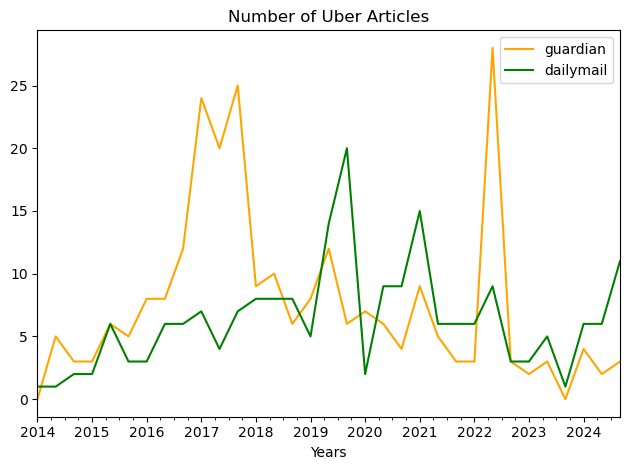

In [ ]:
# This creates the plot that shows number of uber articles by month

# 1. get the data
obj_old = {}
obj = []
with open('./data/final_data.json', encoding='utf-8') as f:
    obj_old = json.load(f)

resolution = 1

def get_frequency_df(obj_old, resolution):
    def func(article, paper):
        article["paper"] = paper
        return article

    for paper in ['guardian', 'dailymail']:
        obj.extend(list(map(lambda x : func(x, paper), obj_old[paper])))

    # What I need is a df of form PAPER/MONTH(everymonth)/COUNT(set0)
    # Need to now earliest month and year and latest month and year (use published)
    # Sort obj by published - do it with data frame

    #df_grouped.plot('monthpub', 'count')
    df = pd.DataFrame.from_records(obj).sort_values('published')
    # Get first timestamps
    first = (df.iloc[0]['published'])
    print(first)
    first = datetime.fromtimestamp(first)

    # ignore 2025
    all_years = [y for y in range(int(first.year), 2024 + 1)]
    all_months = [str(y) + "-" + ("0" if m < 10 else "") + str(m) + "-01" for m in range(1,13) for y in range(first.year, 2025 + 1)]

    # df2 is used only for the time plot

    df2dict = {
        m : {
            'guardian': 0,
            'dailymail': 0
        } for m in all_months
    }

    df2 = pd.DataFrame.from_records(df2dict).transpose()

    def month_function(m):
        return round(((m - 1)//(12/resolution)) * (12/resolution) + 1)

    # months that are possible given resolution
    possible_months = set([month_function(x) for x in range(1,13)])

    print(possible_months)

    # Loop through df
    for index, row in df.iterrows():
        # Convert time to first of given month/year
        month = datetime.fromtimestamp(row['published'])
        # rounded month
        m = month_function(month.month)
        month = month.strftime('%Y-' + ("0" if m < 10 else "") + str(m) + '-01')
        paper = row['paper']
        #month = "2025-01-01"
        # update df2 accordingly
        df2.loc[month, paper] += 1

    #df2.loc[(df2['paper'] == 'guardian') & (df2['month'] == "2025-01-01"), 'count'] = 24

    # convert index to datetime
    df2.index = pd.to_datetime(df2.index)


    # drop months that haven't happened
    # let's ignore 2025 because it hasn't been a full years
    df2= df2[(df2.index.year != 2025)]

    #this step is for accounting for month resolution
    df2 = df2[df2.index.month.isin(possible_months)]
    return df2

df2 = get_frequency_df(obj_old, 3)

plt.figure(figsize=(20, 2), dpi=150)
df2.plot(label="Paper", color=['orange', 'green'])

plt.title('Number of Uber Articles')
plt.xlabel('Years')
# adding legend.
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Remove duplicates in the dataset
loc = "./merged.json"

# check for dupe headlines

obj = []
with open('./data/merged.json', encoding='utf-8') as f:
    obj = json.load(f)

headlines = {
    'guardian': set([]),
    'dailymail': set([])
}

# Loop through articles
n = 0
new_obj = {'guardian' : [], 'dailymail' : []}

for paper in ['guardian', 'dailymail']:
    for article in obj[paper]:
        headline = article['headline'].strip()
        if(headline in headlines[paper]):
            print("DUPE: " + headline)
            n += 1
        else:
            headlines[paper].add(headline)
            new_obj[paper].append(article)

print(n)

with open('./data/merged_nodupe1.json', 'w') as f:
  json.dump(new_obj, f)

In [ ]:
# gonna check for dupes by making dictionary of all authors (and list of authors), and making sure no two similar articles show

obj = []
with open('./data/merged_nodupe1.json', encoding='utf-8') as f:
    obj = json.load(f)

authors_dict = {}

for paper in ['guardian', 'dailymail']:
    for article in obj[paper]:
        index = str([a.strip() for a in article['authors']])
        headline = article['headline'].strip()
        if index not in authors_dict: authors_dict[index] = [headline]
        else: authors_dict[index].append(headline)

# we're only interested in duplicates so remove all authors with multiple entries


n = 0
new_obj = {}

for key in authors_dict.keys():
    if len(authors_dict[key]) < 2:
        n += 1
    else:
        new_obj[key] = authors_dict[key]

print("removed " + str(n) + " authors")

# store remaining authors in file for inspection


with open('./data/dupe_authors.json', 'w') as f:
  json.dump(new_obj, f)



removed 231 authors


In [ ]:
# Install scikit
%pip install nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [60]:
# NLP imports
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# import scipi
from scipy import stats
import math

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
def load_articles(loc):
  with open(loc, encoding='utf-8') as f:
    articles_raw = json.load(f)

  # Format df

  articles = []
  for paper in ['guardian', 'dailymail']:
      for a in articles_raw[paper]:
          a['paper'] = paper
          articles.append(a)

  return pd.DataFrame.from_records(articles)

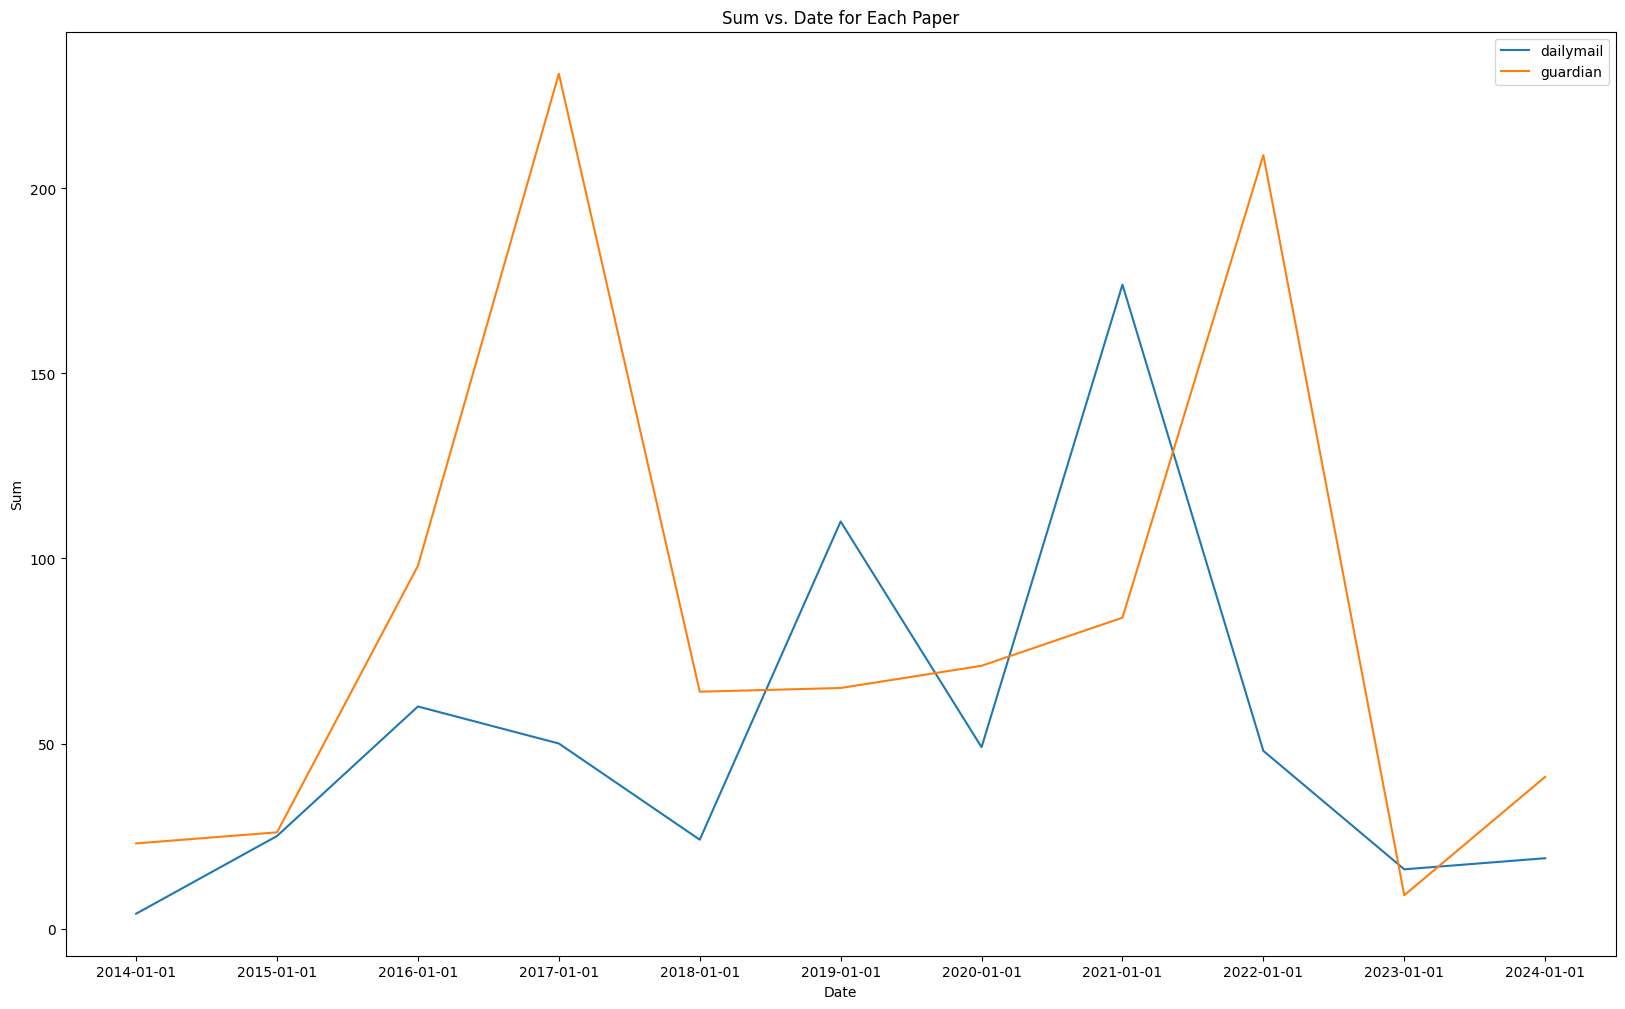

190951
204868


paper,guardian,daily mail expected
(+18%) worker,376,320
(+182%) protest,62,22
(+47%) strike,56,38
(+84%) union,156,85
(+73%) organise,26,15
(+75%) regulate,210,120
(+94%) exploitative,35,18


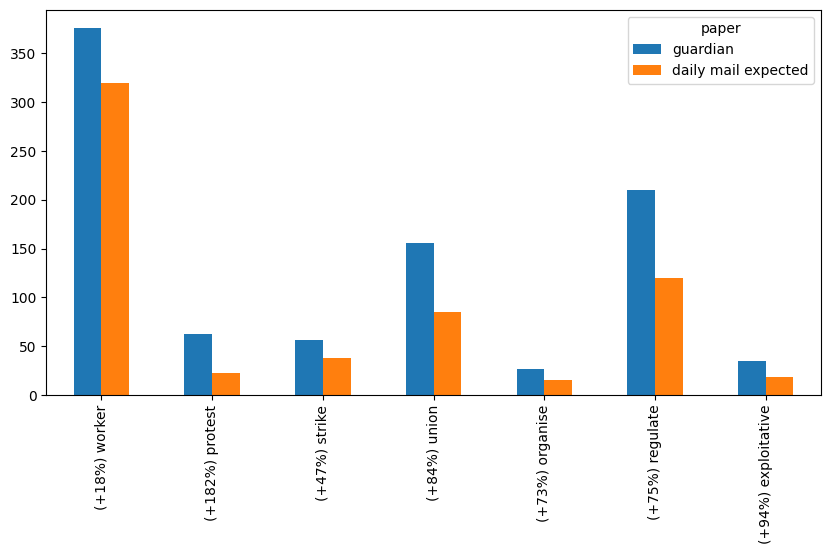

In [81]:
# sentiment analysis of daily mail and uber
# do separately by headline and content
# First exercise - count most frequent words of each article
import json
# Let's try headline first
# First we load the data

df = load_articles('./final_data.json')

def most_frequent_words(text):
    words = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    filtered_words = [stemmer.stem(word) for word in words if word.isalnum() and word not in stop_words]
    filtered_word_counts = Counter(filtered_words)
    return filtered_word_counts.most_common()

# remove all words with compound sentiment between +/-neut (exclusive)
# sentiment dict just to save compute
sent_dict = {}
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    # add single words to sent_dict
    if " " not in text:
      if text not in sent_dict:
          sent_dict[text] = sia.polarity_scores(text)['compound']
      return sent_dict[text]
    else:
        sent_dict[text] = sia.polarity_scores(text)['compound']
        return sent_dict[text]


# Reveals the most important words in an article given
# The frequency of these words in general
def tf_idf_scores(text, neut=0):
    documents = [text]
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(documents)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]
    tfidf_dict = dict(zip(feature_names, tfidf_scores))
    tfidf_dict = dict(sorted(tfidf_dict.items(), key=lambda item: item[1], reverse=True))
    # Remove entries that include numbers because these rarely indicate anything
    for key in list(tfidf_dict.keys()):
        if any(char.isdigit() for char in key) or get_sentiment(key) < neut and get_sentiment(key) > -neut:
            del tfidf_dict[key]
    return tfidf_dict


def collapse_df_dates(df, m_res, y_res = 1):
    # remove 2025 dates because incomplete
    df = df.copy()[df['published'] < 1735689600]
    def month_function(m):
        return round(((m - 1)//(12/m_res)) * (12/m_res) + 1)

    first_year = df['published'].min()
    first_year = datetime.fromtimestamp(first_year)
    first_year = first_year.year

    def year_function(y):
      x = y - first_year
      return (int(math.floor(x / y_res)) * y_res) + first_year

    def date_function(timestamp):
        d = datetime.fromtimestamp(timestamp)
        m = month_function(d.month)
        d = d.replace(month=m, day=1)
        if not y_res == 1: y = year_function(d.year)
        else: y = d.year
        d = d.replace(year=y)
        month = d.strftime('%Y-%m-%d')
        return month

    df['published'] = df['published'].apply(date_function)
    return df

def collapse_df(df, m_res, y_res):
    df = collapse_df_dates(df, m_res, y_res)

    df2 = pd.DataFrame.from_dict({
        "published" : df['published'].unique()
    })
    def concat_headlines(pub):
        x = "\n".join(df[df['published'] == pub]['headline'])
        return x
    def concat_bodies(pub):
        x = "\n".join(df[df['published'] == pub]['body'])
        return x

    df2['headlines'] = df2['published'].apply(concat_headlines)
    df2['bodies'] = df2['published'].apply(concat_bodies)

    # sort by date
    df2 = df2.sort_values(by=['published'])
    df2.set_index('published', inplace=True)
    """df2 = df2.transpose()
    df2 = df2.map(str)"""

    # add missing dates
    first = (df2.index[0])
    first = datetime.strptime(first, '%Y-%m-%d')
    # ignore 2025
    all_years = [y for y in range(int(first.year), 2024 + 1)]
    all_months = [str(y) + "-" + ("0" if (m * (12/m_res) + 1) < 10 else "") + str(int(m * (12/m_res) + 1)) + "-01" for m in range(0,m_res) for y in range(first.year, 2024 + 1)]

    # add month with blank headlines and bodies if not in df
    for month in all_months:
        if month not in df2.index:
          # add row to df
          df2.loc[month] = [""] * len(df2.columns)

    # do tf_idf_scores
    return df2

# could use topic modelling

def df_idf_table(df, top_n, neut = 0):
  df2 = df.copy()
  df2['headlines_tf'] = df['headlines'].apply(tf_idf_scores, neut=neut)
  df2['bodies_tf'] = df['bodies'].apply(tf_idf_scores, neut=neut)
  for i in range(0, top_n):
    df2['h' + str(i)] = df2['headlines_tf'].apply(lambda x: list(x.keys())[i] if i < len(x) else "")
    df2['b' + str(i)] = df2['bodies_tf'].apply(lambda x: list(x.keys())[i] if i < len(x) else "")
  df2.drop(columns=['headlines_tf', 'bodies_tf', 'headlines', 'bodies'], inplace=True)
  # sort by date
  df2 = df2.sort_values(by=['published'])
  df2.set_index('published', inplace=True)
  df2 = df2.transpose()
  df2 = df2.map(str)
  return df2

def heatmap_df(df, m_res = 1, y_res = 1, top_n = 10, neut = 0, paper = None):
  if paper != None:
    df = df.copy()[df['paper'] == paper]
  df = collapse_df(df, m_res, y_res)
  df = df_idf_table(df, 10, neut=0.2)
  df_vals = df.copy().map(get_sentiment)
  fig, ax = plt.subplots(figsize=(20,10))
  sns.heatmap(df_vals, annot=df, fmt="", cmap="icefire_r", vmin=-1, vmax=1)
  plt.show()

def get_topics_text(text):
  vectorizer = TfidfVectorizer(stop_words='english', max_df=.95, min_df=.05)
  article_body_transformed= vectorizer.fit_transform(sent_tokenize(text))
  lda = LatentDirichletAllocation(n_components=16, random_state=42)
  lda.fit(article_body_transformed)
  feature_names = vectorizer.get_feature_names_out()
  for topic_idx, topic in enumerate(lda.components_):
      print(f"Topic {topic_idx}:")
      print(" ".join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]))

#heatmap_df(df, 1, 1, 10, 0.2)

# next try topic modelling
# filter by newspaper
# maybe compute a value which takes into account importance AND sentiment
# make a scatter plot for each paper that plots importance of word (from topic modelling) with sentiment
# i think concat(str) THEN TOPIC MODELLING risks prioritising lowest common denominator words
# e.g. suppose strike is in 50% but DRIVER, UBER are in 100%, then it's gonna be kind of dead
# therefore, collapse after doing the analysis

"""
df_tf = collapse_df(df, 1, y_res=5000)
df_tf['headlines_tf'] = df_tf['headlines'].apply(tf_idf_scores, neut=0)
df_tf['bodies_tf'] = df_tf['bodies'].apply(tf_idf_scores, neut=0)
get_topics_text(df_tf['bodies'][4])
df_tf.head()
"""
import re
def match_word(text, pattern):
  pattern = rf'\b{pattern}\b'
  matches = re.findall(pattern, text)
  return len(matches)


def match_words(df, patterns_dict):
  for pattern in patterns_dict:
    # ignore if word included in columns
    if pattern in df.columns:
      continue
    # Count occurrences of word in bodies preceded and followed by punctuation or space
    # make a pattern of word followed and preceded by punctuation
    df[pattern] = df['bodies'].apply(lambda x : match_word(x, patterns_dict[pattern]))
  df['sum'] = 0
  for pattern in patterns_dict:
    df['sum'] += df[pattern]

  return df


keyword_regexes = {
    'worker' : r'workers?',
    'protest': r'protest(er|ers|ing|ed)?',
    'strike': r'strik(er|es|ers|ing|e)',
    'union' : r'union(ise|s|isation|ising|ised|ize|ization|ized|izing)?',
    'organise' : r'organ(ise|ising|isers|ised|ises|ize|izing|izers|ized)',
    'regulate' : r'regulat(ion|e|ing|or|ions|es|ed|ors)',
    'exploitative' : r'exploit(ative|ing|ed)?'
}



# do guardian and daily mail separately
dfg = collapse_df(df[df['paper'] == 'guardian'], 1, y_res=1)
dfm = collapse_df(df[df['paper'] == 'dailymail'], 1, y_res=1)

dfg = match_words(dfg, keyword_regexes)
dfm = match_words(dfm, keyword_regexes)

# concat
dfg['paper'] = 'guardian'
dfm['paper'] = 'dailymail'
df_matched = pd.concat([dfg, dfm])
df_matched = df_matched.sort_values(by=['published'])
# Create a figure and axes
fig, ax = plt.subplots(figsize=(20, 12))  # Adjust figsize as needed

# Group the dataframe by 'paper' and plot 'sum' against 'published'
for paper, group in df_matched.groupby('paper'):
    ax.plot(group.index, group['sum'], label=paper)

# Set plot title and labels
ax.set_title('Sum vs. Date for Each Paper')
ax.set_xlabel('Date')
ax.set_ylabel('Sum')

# Add a legend
ax.legend()

# Display the plot
plt.show()

df_overall = df_matched.groupby('paper').sum()
# add expected row
df_overall.loc['expected'] = df_overall.loc['dailymail']
# expected row is just how many instances guardian should have if same proportion to daily mail
# i.e. multiply dailymail by how many more words the guardian has (bodies)

dm_words = len(df_overall.loc['dailymail']['bodies'].split())
g_words = len(df_overall.loc['guardian']['bodies'].split())
print(dm_words)
print(g_words)
proportion = g_words / dm_words
# drop bodies and headlines columns
df_overall.drop(columns=['headlines', 'bodies'], inplace=True)
for k in keyword_regexes:
  df_overall.at['expected', k] = int(df_overall.loc['dailymail'][k] * proportion)

# run a bar chart showing expected vs guardian
df_overall.drop(columns=['sum'], inplace=True)
df_overall = df_overall.transpose()
df_overall.drop(columns=['dailymail'], inplace=True)
#rename expected column name
df_overall.rename(columns={'expected': 'daily mail expected'}, inplace=True)
# rename all indexes - add percentage increase

# loop through rows
df_overall.index = "(+" + (round(-100 + 100 * df_overall['guardian'] / df_overall['daily mail expected'])).apply(int).astype(str) + "%) " + df_overall.index
df_overall.plot(kind='bar', figsize=(10, 5))

df_overall.head(20)

<Axes: ylabel='Number of words total'>

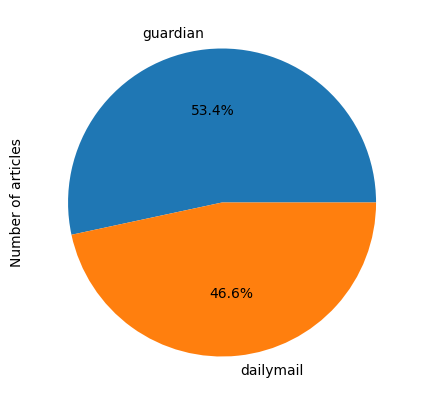

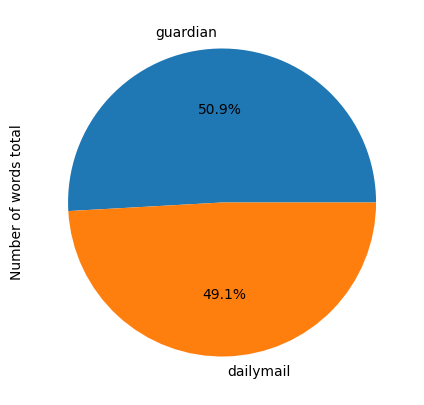

In [14]:
# This block will just display how many articles from each paper
# And combined length of all articles from each paper
df = load_articles('./final_data.json')
# Count all where paper = daily mail and guardian
df_count = df['paper'].value_counts().reset_index()
df_count.columns = ['paper', 'count']
df_count = df_count.set_index('paper')
# Load dataframe

# combined length
# append all bodies of each paper
df_count['bodies_size'] = df.groupby('paper')['body'].apply(lambda x: len(' '.join(x).split()))

# create a pie chart of each paper's count
df_count.plot.pie(y='count', figsize=(5, 5), autopct='%1.1f%%', ylabel='Number of articles', legend=False)
df_count

# create a pie chart of bodies size
df_count.plot.pie(y='bodies_size', figsize=(5, 5), autopct='%1.1f%%', ylabel='Number of words total', legend=False)